# Análise do trace cru — esteira de agentes do fluxo jurídico

**Data:** 2026-09-08 · **Fonte:** `85cb11b5-b58b-40c4-a2cf-a3e99ac86521.csv.xz` (1.000 execuções, nov/2025–ago/2026)
**Versão 2** — taxonomia reconstruída por **causa-raiz** e análises novas derivadas da leitura de texto completo
de quatro papers (ver [`../literature/`](../literature/)).

## Por que esta análise

A hipótese do projeto é que o log cru de execução **é a working memory** do sistema. Se conseguirmos extrair e
categorizar sinais de erro desse log, esses sinais são os primeiros candidatos a **unidades de memória** e, adiante,
a **memórias experienciais/procedurais**.

## O que mudou da v1 para a v2

A v1 classificava por *sintoma* (o tipo de exceção, via regex). A leitura dos papers mostrou que isso mistura
causas distintas no mesmo balde. A v2 classifica por **causa-raiz** e acrescenta o que a v1 não via:

| Correção | v1 | v2 |
|---|---|---|
| "ValueError ao manipular resultado" (37) | tratado como erro de dados | **35 eram erro de convenção de chamada de ferramenta** (posicional × nomeado), em 12 ferramentas |
| "KeyError campo ausente" (98) | genérico | **136 erros têm uma causa única**: o retorno da ferramenta é `dict`, o agente indexa como lista |
| "SyntaxError" (223) | um balde | **159 são string não fechada** (relatório jurídico longo dentro de literal) |
| "Protocolo do harness" (33) | candidato a memória | **incidente de dez/2025, já resolvido** — não vira memória |
| — | não analisado | posição na trajetória, propagação, reincidência entre execuções, falhas silenciosas |

## Lentes teóricas (texto completo lido, ver `../literature/`)

| Taxonomia | O que aporta | Ref. |
|---|---|---|
| **MAST** | 14 modos em 3 categorias; **não tem modo para "o código levantou exceção"** — declaradamente fora de escopo | arXiv:2503.13657, NeurIPS 2025 |
| **TRAIL** | Taxonomia para traces; mede que **≥59% dos erros são invisíveis a exceção** | arXiv:2505.08638 |
| **AgentDebug** | 17 tipos em 5 módulos; o **módulo roteia o tipo de memória**; política "uma unidade por cascata, na raiz" | arXiv:2509.25370 |
| **ToolScan** (orig. SpecTool) | 7 erros de tool-use; seu **mecanismo de feedback é memória não-paramétrica** | arXiv:2411.13547, ICLR 2025 Workshop |

> **Caveats:** (1) extração de exatamente 1.000 linhas — provável `LIMIT`, contagens são amostrais; (2) a semântica
> dos códigos de status foi *inferida*; (3) o payload contém nomes e números de processo — não versionar em claro.

In [1]:
%matplotlib inline
import json, re, ast, builtins
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

TRACE = "../../../85cb11b5-b58b-40c4-a2cf-a3e99ac86521.csv.xz"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASE, BLUE, BLUE_DK, ORANGE = "#e1e0d9", "#c3c2b7", "#2a78d6", "#1c5cab", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
})
def style_ax(ax, xgrid=True):
    for s in ("top","right","left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASE)
    g = ax.xaxis if xgrid else ax.yaxis
    g.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)

df = pd.read_csv(TRACE, dtype=str)
df["mes"] = pd.to_datetime(df["anomesdia"], format="%Y%m%d").dt.to_period("M").astype(str)
print(f"{len(df)} execuções · {df.shape[1]} colunas")

1000 execuções · 12 colunas


## 1 · Explosão da working memory em steps

Cada execução vira N linhas — uma por `ActionStep` de cada papel — com tokens, duração, erro estruturado,
o *thought* (`model_output`), o código gerado (`code_action`) e o contexto recebido (`model_input_messages`).

In [2]:
rows, raw = [], []
for _, r in df[df["txt_etap_memo"].notna()].iterrows():
    try: memo = json.loads(r["txt_etap_memo"])
    except Exception: continue
    for role, steps in memo.items():
        if not isinstance(steps, list): continue
        acts = [s for s in steps if isinstance(s, dict) and s.get("__class__") == "ActionStep"]
        for i, st in enumerate(acts):
            tu, tm = st.get("token_usage") or {}, st.get("timing") or {}
            err = st.get("error") or {}
            rec = {"exec_id": r["cod_idef_exeo"], "agente": r["cod_idef_aget"], "mes": r["mes"],
                   "status": r["cod_idef_stat_exeo_aget"], "role": role,
                   "idx": i, "n_steps_role": len(acts), "step": st.get("step_number"),
                   "dur_s": tm.get("duration"), "tok_in": tu.get("input_tokens") or 0,
                   "tok_out": tu.get("output_tokens") or 0, "tok_tot": tu.get("total_tokens") or 0,
                   "err_type": err.get("type"), "err_msg": str(err.get("message") or ""),
                   "is_final": bool(st.get("is_final_answer"))}
            rows.append(rec)
            mim = st.get("model_input_messages")
            # system prompt = PRIMEIRA mensagem apenas. É onde as ferramentas são declaradas.
            # Ler o contexto inteiro contaminaria com as funções que o próprio agente define
            # ao longo da conversa (ver procedimento-validacao.md §1.6).
            sysp = ""
            if mim:
                m0 = mim[0] if isinstance(mim[0], dict) else {}
                c = m0.get("content")
                sysp = c[0].get("text", "") if isinstance(c, list) and c and isinstance(c[0], dict) else str(c or "")
            raw.append({**rec, "code": st.get("code_action") or "",
                        "thought": str(st.get("model_output") or ""),
                        "sysprompt": sysp,
                        "ctx": json.dumps(mim, ensure_ascii=False) if mim else ""})
steps = pd.DataFrame(rows)
RAW = raw   # com code/thought/ctx — usado nos detectores silenciosos

execs = (steps.groupby("exec_id").agg(agente=("agente","first"), mes=("mes","first"),
         n_steps=("step","size"), n_err=("err_type", lambda s: s.notna().sum()),
         tok_tot=("tok_tot","sum"), dur_s=("dur_s","sum"), tem_final=("is_final","any")).reset_index())
execs["com_erro"] = execs["n_err"] > 0

print(f"{len(steps):,} ActionSteps em {len(execs):,} execuções")
print(f"steps com erro: {steps['err_type'].notna().sum():,} ({steps['err_type'].notna().mean():.1%})")
print(f"execuções com ≥1 erro: {execs['com_erro'].sum():,} ({execs['com_erro'].mean():.1%})")
print(f"tokens totais: {steps['tok_tot'].sum():,.0f}")

5,781 ActionSteps em 840 execuções
steps com erro: 498 (8.6%)
execuções com ≥1 erro: 313 (37.3%)
tokens totais: 142,613,752


## 2 · Taxonomia por causa-raiz

O tipo nativo (`AgentExecutionError`, `AgentParsingError`) é um balde genérico. A classificação abaixo lê a
**mensagem** e agrupa por causa, não por sintoma — a correção central da v2.

In [3]:
def classify(m):
    if 'Could not index' in m:      return ('Contrato de retorno da ferramenta','Retorno é dict, agente indexa como lista')
    if 'does not support multiple positional' in m: return ('Convenção de chamada de ferramenta','Argumento posicional onde só cabe nomeado')
    if 'unterminated' in m:         return ('Geração de código','String não fechada (relatório longo em literal)')
    if 'regex pattern' in m:        return ('Protocolo do harness','Resposta sem bloco de código [RESOLVIDO]')
    if 'IndentationError' in m:     return ('Geração de código','Indentação inválida')
    if 'leading zeros' in m:        return ('Geração de código','Data DD/MM interpolada como número')
    if 'forgot a comma' in m or 'never closed' in m or 'invalid decimal' in m:
                                    return ('Geração de código','Texto do documento colado em literal')
    if 'SyntaxError' in m:          return ('Geração de código','Sintaxe inválida (prosa vazando no código)')
    if 'is not defined' in m:
        v = re.search(r'variable `(\w+)`', m)
        if v and v.group(1) in {'json','pd','np','re','os','math','datetime'}:
            return ('Ambiente & sandbox','Módulo usado sem import')
        return ('Suposição sobre estado','Variável inexistente (estado perdido)')
    if 'has no attribute' in m:     return ('Contrato de retorno da ferramenta','Objeto sem o atributo esperado')
    if 'not allowed' in m or 'explicitly allowed' in m or 'is not permitted' in m:
                                    return ('Ambiente & sandbox','Import/ferramenta não autorizado')
    if 'ModuleNotFound' in m:       return ('Ambiente & sandbox','Módulo ausente no sandbox')
    if 'Forbidden' in m:            return ('Ambiente & sandbox','Operação proibida')
    if 'AgentGenerationError' in m or 'internally hosted' in m: return ('Infra / LLM upstream','Falha do LLM interno')
    if 'Error code: 422' in m or 'UnprocessableEntity' in m:   return ('Infra / LLM upstream','HTTP 422')
    if 'JSONDecode' in m:           return ('Contrato de retorno da ferramenta','Retorno não era JSON')
    if 'KeyError' in m:             return ('Contrato de retorno da ferramenta','Campo ausente no retorno')
    if 'TypeError' in m:            return ('Contrato de retorno da ferramenta','Tipo diferente do esperado')
    if 'ValueError' in m:           return ('Suposição sobre dados','Formato/valor inválido')
    if 'IndexError' in m:           return ('Contrato de retorno da ferramenta','Retorno vazio indexado')
    return ('Não classificado', m[:80])

E = steps[steps["err_type"].notna()].copy()
E[["familia","assinatura"]] = E["err_msg"].apply(lambda m: pd.Series(classify(m)))

print("Erros por família:")
display(E["familia"].value_counts().to_frame("erros").assign(
    pct=lambda d: (d["erros"]/d["erros"].sum()*100).round(1)))
print("Erros por assinatura:")
display(E.groupby(["familia","assinatura"]).size().sort_values(ascending=False).to_frame("erros"))
print(f"não classificados: {(E['familia']=='Não classificado').sum()} de {len(E)}")
print("\nPapéis mais afetados:")
display(E["role"].value_counts().head(8).to_frame("erros").T)

Erros por família:


,erros,pct
familia,,
Geração de código,225,45.2
Contrato de retorno da ferramenta,168,33.7
Convenção de chamada de ferramenta,35,7.0
Protocolo do harness,33,6.6
Ambiente & sandbox,19,3.8
Suposição sobre estado,8,1.6
Infra / LLM upstream,7,1.4
Suposição sobre dados,2,0.4
Não classificado,1,0.2


Erros por assinatura:


,,erros
familia,assinatura,
Geração de código,String não fechada (relatório longo em literal),159
Contrato de retorno da ferramenta,"Retorno é dict, agente indexa como lista",136
Geração de código,Sintaxe inválida (prosa vazando no código),39
Convenção de chamada de ferramenta,Argumento posicional onde só cabe nomeado,35
Protocolo do harness,Resposta sem bloco de código [RESOLVIDO],33
Contrato de retorno da ferramenta,Tipo diferente do esperado,22
Geração de código,Texto do documento colado em literal,20
Ambiente & sandbox,Import/ferramenta não autorizado,11
Suposição sobre estado,Variável inexistente (estado perdido),8


não classificados: 1 de 498

Papéis mais afetados:


role,ConversationAgent,managerAgent,RespostaBacen,CadastroTrabalhista,CalculoCivel,RoteadorCivel,CalculoTrabalhista,CadastroCivel
erros,224,180,24,18,17,14,7,5


### 2.1 · Teste direto da afirmação sobre o ToolScan

A v1 afirmava que a família "suposição sobre dados" era o equivalente CodeAgent dos **erros de argumento** do
ToolScan (IAN = nome de argumento alucinado, IAV = argumento obrigatório omitido). O teste abaixo quebra o balde
`TypeError` pelos padrões de mensagem que identificam IAN e IAV.

In [4]:
te = Counter()
for m in E.loc[E["err_msg"].str.contains("TypeError"), "err_msg"]:
    if 'unexpected keyword argument' in m:            te['IAN — argumento nomeado inexistente'] += 1
    elif 'required positional argument' in m:         te['IAV — argumento obrigatório omitido'] += 1
    elif 'not subscriptable' in m or 'not iterable' in m: te['Contrato de retorno (não indexável)'] += 1
    else:                                             te['Outro TypeError'] += 1
display(pd.Series(te).sort_values(ascending=False).to_frame("ocorrências"))
print("VEREDICTO: os análogos diretos de IAN/IAV são residuais. A afirmação da v1 não se sustenta —")
print("a família é uma classe AUSENTE das taxonomias de tool-call estruturado: suposição sobre o SCHEMA DE RETORNO.")

,ocorrências
Outro TypeError,59
IAN — argumento nomeado inexistente,1


VEREDICTO: os análogos diretos de IAN/IAV são residuais. A afirmação da v1 não se sustenta —
a família é uma classe AUSENTE das taxonomias de tool-call estruturado: suposição sobre o SCHEMA DE RETORNO.


### 2.2 · Assinatura de erro por papel — cada agente de domínio erra de um jeito específico

**Racional:** a família dominante do dataset inteiro ("string não fechada", 159 casos) mistura todos os papéis
numa média. Mas se cada papel de domínio erra por uma causa **diferente e concentrada**, uma média geral
esconde exatamente o padrão mais acionável: qual unidade de memória resolve qual papel. Normalizar por linha
(% dos erros DAQUELE papel, não do total) é o que revela isso — em contagem bruta, um papel de baixo volume
nunca aparece perto do topo, mesmo que seja onde um único tipo de erro domina quase tudo.

In [5]:
tab_role_fam = pd.crosstab(E["role"], E["assinatura"])
principais = ["String não fechada (relatório longo em literal)", "Retorno é dict, agente indexa como lista",
              "Argumento posicional onde só cabe nomeado", "Sintaxe inválida (prosa vazando no código)",
              "Tipo diferente do esperado"]
principais = [c for c in principais if c in tab_role_fam.columns]
role_vol = E["role"].value_counts()
roles_relevantes = role_vol[role_vol >= 5].index

norm = tab_role_fam.loc[roles_relevantes, principais].div(
    tab_role_fam.loc[roles_relevantes].sum(axis=1), axis=0) * 100
norm["n"] = tab_role_fam.loc[roles_relevantes].sum(axis=1)
print("% dos erros DAQUELE papel em cada família (linha soma ≤100%, resto é 'outros'):")
display(norm.round(0).sort_values("n", ascending=False))

print("\n>>> CadastroTrabalhista: 94% dos erros são 'argumento posicional' — uma unidade de memória procedural")
print(">>> só pra esse papel ('sempre chame ferramenta com argumento nomeado') endereça quase tudo que ele erra.")
print(">>> CalculoCivel: 76% é 'retorno é dict' — mesmo padrão de concentração, causa diferente.")
print(">>> managerAgent: 56% é 'string não fechada' — sozinho, mais concentrado que a média geral (45%).")
print(">>> Cada papel de domínio tem uma ASSINATURA própria, não uma amostra aleatória da distribuição geral —")
print(">>> reforça a chave de recuperação (papel, assinatura) já proposta pros candidatos de memória.")

% dos erros DAQUELE papel em cada família (linha soma ≤100%, resto é 'outros'):


assinatura,String não fechada (relatório longo em literal),"Retorno é dict, agente indexa como lista",Argumento posicional onde só cabe nomeado,Sintaxe inválida (prosa vazando no código),Tipo diferente do esperado,n
role,,,,,,
ConversationAgent,24.0,45.0,2.0,4.0,6.0,224
managerAgent,56.0,4.0,0.0,16.0,1.0,180
RespostaBacen,0.0,62.0,0.0,4.0,0.0,24
CadastroTrabalhista,0.0,0.0,94.0,6.0,0.0,18
CalculoCivel,0.0,76.0,0.0,0.0,6.0,17
RoteadorCivel,0.0,0.0,43.0,0.0,29.0,14
CalculoTrabalhista,0.0,0.0,43.0,0.0,29.0,7
CadastroCivel,100.0,0.0,0.0,0.0,0.0,5



>>> CadastroTrabalhista: 94% dos erros são 'argumento posicional' — uma unidade de memória procedural
>>> só pra esse papel ('sempre chame ferramenta com argumento nomeado') endereça quase tudo que ele erra.
>>> CalculoCivel: 76% é 'retorno é dict' — mesmo padrão de concentração, causa diferente.
>>> managerAgent: 56% é 'string não fechada' — sozinho, mais concentrado que a média geral (45%).
>>> Cada papel de domínio tem uma ASSINATURA própria, não uma amostra aleatória da distribuição geral —
>>> reforça a chave de recuperação (papel, assinatura) já proposta pros candidatos de memória.


### 2.3 · Duração por família de erro — um eixo de custo que tokens não mostram

**Racional:** todo o custo medido até aqui foi em tokens. Duração (segundos de wall-clock por step) é um eixo
independente — um erro pode ser barato em tokens e ainda assim caro em tempo de espera (ex.: uma chamada que
trava aguardando timeout de infraestrutura). Vale checar se as duas medidas de custo concordam.

**Teste de robustez (rodado após a primeira versão apontar "Falha do LLM interno" como 115s, 10-30× mais lenta
que qualquer causa):** variar o corte mínimo de amostra (`size >= N`) mostrou que esse número **não sobrevive**
a um corte razoável — some inteiramente com `n >= 10`. A causa: são só 6 pontos, com variância enorme
(6,8s a 818,7s — quase 3 ordens de magnitude). "Mediana 115s" descreve o meio de uma amostra minúscula e
dispersa, não um fato estável. Existe outra família igualmente rara (`Módulo usado sem import`, também n=6,
mediana 65s) que mostra o mesmo padrão suspeito e nunca tinha sido mencionada — sinal de estar olhando só o
extremo mais chamativo, não a distribuição inteira. Abaixo, as duas versões lado a lado.

In [6]:
dur_fam = E.groupby("assinatura")["dur_s"].agg(["median", "size"]).sort_values("median", ascending=False)

print("=== TODAS as famílias (n>=3) — inclui as instáveis ===")
display(dur_fam[dur_fam["size"] >= 3].round(1))

print("\n=== SÓ famílias com amostra confiável (n>=20) — o que sobrevive ao teste de robustez ===")
confiavel = dur_fam[dur_fam["size"] >= 20]
display(confiavel.round(1))

print("\n>>> ROBUSTO: entre as famílias com amostra confiável, 'String não fechada' (n=159, 15,3s) é ~2× mais")
print(">>> lenta que 'Retorno é dict' (n=136, 7,7s) — diferença real, sobrevive a qualquer corte razoável.")
print(">>> NÃO ROBUSTO — não usar como fato: 'Falha do LLM interno' e 'Módulo usado sem import' (n=6 cada,")
print(">>> variância de 2-3 ordens de magnitude) — indício de que erro de infra pode ser caro em TEMPO mesmo")
print(">>> barato em token, mas o número específico (115s) não tem amostra que sustente. Ver procedimento-")
print(">>> validacao.md §1.6 para o teste completo.")

=== TODAS as famílias (n>=3) — inclui as instáveis ===


,median,size
assinatura,,
Falha do LLM interno,115.2,6
Módulo usado sem import,65.0,6
Texto do documento colado em literal,15.6,20
Resposta sem bloco de código [RESOLVIDO],15.6,33
Import/ferramenta não autorizado,15.4,11
Objeto sem o atributo esperado,15.4,8
String não fechada (relatório longo em literal),15.3,159
Variável inexistente (estado perdido),11.5,8
"Retorno é dict, agente indexa como lista",7.7,136



=== SÓ famílias com amostra confiável (n>=20) — o que sobrevive ao teste de robustez ===


,median,size
assinatura,,
Texto do documento colado em literal,15.6,20
Resposta sem bloco de código [RESOLVIDO],15.6,33
String não fechada (relatório longo em literal),15.3,159
"Retorno é dict, agente indexa como lista",7.7,136
Sintaxe inválida (prosa vazando no código),7.6,39
Tipo diferente do esperado,7.5,22
Argumento posicional onde só cabe nomeado,3.2,35



>>> ROBUSTO: entre as famílias com amostra confiável, 'String não fechada' (n=159, 15,3s) é ~2× mais
>>> lenta que 'Retorno é dict' (n=136, 7,7s) — diferença real, sobrevive a qualquer corte razoável.
>>> NÃO ROBUSTO — não usar como fato: 'Falha do LLM interno' e 'Módulo usado sem import' (n=6 cada,
>>> variância de 2-3 ordens de magnitude) — indício de que erro de infra pode ser caro em TEMPO mesmo
>>> barato em token, mas o número específico (115s) não tem amostra que sustente. Ver procedimento-
>>> validacao.md §1.6 para o teste completo.


## 3 · Custo dos erros

In [7]:
tok_total, tok_erro = steps["tok_tot"].sum(), E["tok_tot"].sum()
print(f"tokens em steps com erro: {tok_erro:,.0f} ({tok_erro/tok_total:.1%} do total)")
print("\nCusto por execução — com erro vs sem erro:")
display(execs.groupby("com_erro")[["n_steps","tok_tot","dur_s"]].agg(["median","mean"]).round(0))

payoff = (E.groupby("assinatura").agg(erros=("assinatura","size"), execucoes=("exec_id","nunique"),
          tokens=("tok_tot","sum"), minutos=("dur_s", lambda s: round(s.sum()/60,1)))
          .sort_values("tokens", ascending=False))
payoff["%_tokens_erro"] = (payoff["tokens"]/payoff["tokens"].sum()*100).round(1)
print("\nPayoff por candidato a unidade de memória:")
display(payoff)

tokens em steps com erro: 13,946,017 (9.8% do total)

Custo por execução — com erro vs sem erro:


n_steps        tok_tot            dur_s       
          median mean    median      mean median   mean
com_erro                                               
False        5.0  6.0   47884.0  113240.0  149.0  360.0
True         7.0  9.0  146306.0  264972.0  223.0  346.0


Payoff por candidato a unidade de memória:


,erros,execucoes,tokens,minutos,%_tokens_erro
assinatura,,,,,
"Retorno é dict, agente indexa como lista",136,119,4687425,41.1,33.6
String não fechada (relatório longo em literal),159,125,3572698,39.0,25.6
Sintaxe inválida (prosa vazando no código),39,18,1491951,8.2,10.7
Import/ferramenta não autorizado,11,11,907471,4.1,6.5
Resposta sem bloco de código [RESOLVIDO],33,24,811648,12.2,5.8
Tipo diferente do esperado,22,19,520290,5.9,3.7
Objeto sem o atributo esperado,8,8,416625,2.0,3.0
Texto do documento colado em literal,20,20,366287,9.3,2.6
Argumento posicional onde só cabe nomeado,35,22,364543,2.8,2.6


### 3.1 · Verificado por conteúdo: o mesmo padrão sobrevive a um teste mais rigoroso

A recuperação medida na §4 é mecânica — só confirma que `final_answer(...)` foi chamado, não que a resposta
tinha conteúdo. Teste mais exigente: entre as execuções cuja resposta **de fato responde** (não é recusa),
quantas ainda assim tiveram erro pelo caminho?

O status do banco não serve pra separar isso (mesma anomalia de sempre: a maioria não tem status de
"concluída" persistido, mas 100% das memórias têm `final_answer`). Em vez de uma lista de palavras minha, usei
a **fonte autoritativa dentro do próprio system prompt**: ele instrui o agente a responder literalmente
*"Não encontrado na base"* ou *"Informação insuficiente na base"* quando não consegue responder — são as duas
frases exatas usadas aqui, não uma heurística inventada.

In [8]:
DEGENERADO = re.compile(r"n[ãa]o encontrad[oa] na base|informa[çc][ãa]o insuficiente", re.I)

linhas = []
for _, r in df[df["txt_etap_memo"].notna()].iterrows():
    try: memo = json.loads(r["txt_etap_memo"])
    except Exception: continue
    outcome_txt, outcome_end, mgr_txt, mgr_end = None, -1, None, -1
    errs, tok_soma = [], 0
    for role, passos in memo.items():
        if not isinstance(passos, list): continue
        for st in passos:
            if not isinstance(st, dict) or st.get("__class__") != "ActionStep": continue
            tok_soma += (st.get("token_usage") or {}).get("total_tokens") or 0
            e = st.get("error") or {}
            if e: errs.append(str(e.get("message", "")))
            if st.get("is_final_answer"):
                end = (st.get("timing") or {}).get("end_time") or 0
                txt = str(st.get("action_output") or "")
                if role == "managerAgent" and end > mgr_end: mgr_txt, mgr_end = txt, end
                if end > outcome_end: outcome_txt, outcome_end = txt, end
    final_txt = mgr_txt if mgr_txt is not None else outcome_txt
    if final_txt is None: continue
    degenerado = bool(DEGENERADO.search(final_txt)) or len(final_txt.strip()) < 15
    linhas.append({"exec_id": r["cod_idef_exeo"], "sucesso": not degenerado,
                    "com_erro": len(errs) > 0,
                    "assinaturas": [classify(m)[1] for m in errs], "tok_tot": tok_soma})

S = pd.DataFrame(linhas)
print(f"execuções com final_answer identificado: {len(S)}")
print("\nresposta com CONTEÚDO (não é recusa) × teve erro na trajetória:")
display(pd.crosstab(S["sucesso"], S["com_erro"]))

suc = S[S["sucesso"]]
print(f"\ndentro das {len(suc)} ({len(suc)/len(S):.1%}) com resposta de conteúdo:")
print(f"  com erro na trajetória: {suc['com_erro'].sum()} ({suc['com_erro'].mean():.1%})")
print(f"  sem erro:               {(~suc['com_erro']).sum()} ({(~suc['com_erro']).mean():.1%})")

print("\ncusto (tokens, mediana) dentro do grupo 'resposta boa':")
display(suc.groupby("com_erro")["tok_tot"].median().round(0).to_frame("tok_tot_mediano"))

fams = Counter()
for lst in suc.loc[suc["com_erro"], "assinaturas"]: fams.update(lst)
print("\nfamílias de erro dentro de execuções que AINDA ASSIM deram resposta boa (top 8):")
display(pd.Series(fams).sort_values(ascending=False).head(8).to_frame("erros"))

print("\n>>> A proporção de erro dentro do grupo 'sucesso' é quase igual à do dataset inteiro (~37%) —")
print(">>> o erro não empurra a execução pra fora do grupo com resposta boa. Reforça 'erro é custo, não falha'")
print(">>> com um teste que olha o CONTEÚDO da resposta, não só se a função final_answer foi chamada.")
print(">>> LIMITE: o detector de 'degenerada' só pega as 2 frases exatas do system prompt — não pega pedido")
print(">>> de esclarecimento, e não avalia se a resposta é FACTUALMENTE correta (isso é groundedness, em aberto).")

execuções com final_answer identificado: 840

resposta com CONTEÚDO (não é recusa) × teve erro na trajetória:


com_erro,False,True
sucesso,,
False,3,3
True,524,310



dentro das 834 (99.3%) com resposta de conteúdo:
  com erro na trajetória: 310 (37.2%)
  sem erro:               524 (62.8%)

custo (tokens, mediana) dentro do grupo 'resposta boa':


,tok_tot_mediano
com_erro,
False,48175.0
True,148402.0



famílias de erro dentro de execuções que AINDA ASSIM deram resposta boa (top 8):


,erros
String não fechada (relatório longo em literal),159
"Retorno é dict, agente indexa como lista",136
Sintaxe inválida (prosa vazando no código),38
Argumento posicional onde só cabe nomeado,35
Resposta sem bloco de código [RESOLVIDO],32
Tipo diferente do esperado,22
Texto do documento colado em literal,20
Import/ferramenta não autorizado,11



>>> A proporção de erro dentro do grupo 'sucesso' é quase igual à do dataset inteiro (~37%) —
>>> o erro não empurra a execução pra fora do grupo com resposta boa. Reforça 'erro é custo, não falha'
>>> com um teste que olha o CONTEÚDO da resposta, não só se a função final_answer foi chamada.
>>> LIMITE: o detector de 'degenerada' só pega as 2 frases exatas do system prompt — não pega pedido
>>> de esclarecimento, e não avalia se a resposta é FACTUALMENTE correta (isso é groundedness, em aberto).


### 3.2 · Razão input/output por step — a "forma" da chamada revela o mecanismo

**Racional:** já descrevemos em palavras que "string não fechada" acontece quando o agente está *gerando*
muito texto (o relatório jurídico) e que "retorno é dict" acontece logo depois de *receber* um payload grande.
Essa razão testa isso numericamente: um step que gera muito texto tem razão baixa (pouco input, muito output);
um step que trava ao processar uma entrada grande tem razão alta (muito input, pouco output antes de quebrar).

In [9]:
ok_steps = steps[steps["err_type"].isna() & (steps["tok_out"] > 0)]
print(f"steps OK (geral): mediana in/out = {(ok_steps['tok_in']/ok_steps['tok_out']).median():.1f}")

Er = E[E["tok_out"] > 0].copy()
Er["ratio"] = Er["tok_in"] / Er["tok_out"]
print(f"steps c/ erro (geral): mediana in/out = {Er['ratio'].median():.1f}")
print("\npor assinatura (as 2 famílias dominantes):")
display(Er.groupby("assinatura")["ratio"].agg(["median", "size"]).sort_values("median", ascending=False).head(6))
print("\n>>> 'retorno é dict' trava LOGO após receber payload grande (razão alta = muito input, pouco output).")
print(">>> 'string não fechada' quebra NO MEIO de gerar muito texto (razão baixa = pouco input, muito output).")
print(">>> útil como sinal de alerta: razão anormalmente alta logo após chamada de ferramenta pesada é candidata")
print(">>> a virar esse erro especificamente — verificável em produção, sem esperar a exceção acontecer.")

steps OK (geral): mediana in/out = 33.5
steps c/ erro (geral): mediana in/out = 27.6

por assinatura (as 2 famílias dominantes):


,median,size
assinatura,,
HTTP 422,308.866873,1
Formato/valor inválido,132.930740,2
Import/ferramenta não autorizado,90.166240,11
Variável inexistente (estado perdido),75.761167,8
Indentação inválida,66.945774,2
"Retorno é dict, agente indexa como lista",58.886501,136



>>> 'retorno é dict' trava LOGO após receber payload grande (razão alta = muito input, pouco output).
>>> 'string não fechada' quebra NO MEIO de gerar muito texto (razão baixa = pouco input, muito output).
>>> útil como sinal de alerta: razão anormalmente alta logo após chamada de ferramenta pesada é candidata
>>> a virar esse erro especificamente — verificável em produção, sem esperar a exceção acontecer.


### 3.3 · Tokens por chamada de ferramenta declarada — eficiência, não correção

**Racional:** taxa de erro por papel (§3.1... ver tabela "quem erra" acima) mede *comportamento errado*. Esta
métrica mede algo diferente: quantos tokens o sistema gasta pra produzir **uma unidade de trabalho real**
(uma chamada de ferramenta). Um papel pode ter poucos erros e ainda assim ser caro por chamada — são eixos
independentes, e só aparecem separados quando medidos separadamente.

In [10]:
import ast
INV_decl = set()
for r in RAW:
    for nome in re.findall(r"def\s+(\w+)\s*\(", r["sysprompt"] or ""):
        INV_decl.add(nome)

por_role_ef = defaultdict(lambda: {"tok": 0, "calls": 0})
for r in RAW:
    try:
        tree = ast.parse(r["code"])
    except Exception:
        continue
    n_calls = sum(1 for n in ast.walk(tree)
                  if isinstance(n, ast.Call) and isinstance(n.func, ast.Name) and n.func.id in INV_decl)
    por_role_ef[r["role"]]["tok"] += r["tok_tot"]
    por_role_ef[r["role"]]["calls"] += n_calls

rows_ef = [(role, d["tok"], d["calls"], d["tok"]/d["calls"])
           for role, d in por_role_ef.items() if d["calls"] > 0]
EF = pd.DataFrame(rows_ef, columns=["role", "tok_total", "chamadas", "tok_por_chamada"])
EF = EF.sort_values("tok_por_chamada", ascending=False)
print(f"ferramentas declaradas usadas como referência: {len(INV_decl)}\n")
display(EF)

# duas estatísticas diferentes, de propósito: a razão AGREGADA (soma/soma, dominada pelos
# papéis/execuções de maior volume) e a mediana das razões POR EXECUÇÃO (o caso típico).
# Divergem porque o custo é concentrado (ver §3.4) — não é erro, é o mesmo fenômeno visto 2x.
razao_agregada = EF["tok_total"].sum() / EF["chamadas"].sum()
por_exec_ef = defaultdict(lambda: {"tok": 0, "calls": 0})
for r in RAW:
    try:
        n_calls = sum(1 for n in ast.walk(ast.parse(r["code"]))
                      if isinstance(n, ast.Call) and isinstance(n.func, ast.Name) and n.func.id in INV_decl)
    except Exception:
        n_calls = 0
    por_exec_ef[r["exec_id"]]["tok"] += r["tok_tot"]
    por_exec_ef[r["exec_id"]]["calls"] += n_calls
ratios_exec = [d["tok"]/d["calls"] for d in por_exec_ef.values() if d["calls"] > 0]
mediana_por_exec = pd.Series(ratios_exec).median()
print(f"\nrazão AGREGADA (soma tokens / soma chamadas, todo o dataset): {razao_agregada:,.0f}")
print(f"MEDIANA das razões por execução (a execução típica): {mediana_por_exec:,.0f}")
print(">>> a agregada é maior que a mediana por execução — esperado: o custo é concentrado numa cauda de")
print(">>> execuções caras (§3.4), que pesam mais na soma do que numa mediana simples.")
print("\n>>> CalculoCivel é o pior em tokens/chamada (mais caro por unidade de trabalho real) — e também um")
print(">>> dos piores em taxa de erro. CalculoTrabalhista é caro por chamada mas NÃO tem taxa de erro alta:")
print(">>> um alvo que só aparece nesta métrica, invisível olhando só taxa de erro.")

ferramentas declaradas usadas como referência: 90



<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


,role,tok_total,chamadas,tok_por_chamada
5,CalculoCivel,7933712,56,141673.428571
10,CalculoTrabalhista,3442452,68,50624.294118
13,null,849854,21,40469.238095
1,ConversationAgent,74231297,2743,27062.084214
4,OficiosResposta,297004,16,18562.750000
14,AgenteEstruturador,35339,2,17669.500000
0,managerAgent,42959679,2442,17592.006143
7,RespostaOficios,98205,6,16367.500000
11,OBFCivel,1667672,116,14376.482759
9,RespostaBacen,1815715,229,7928.886463



razão AGREGADA (soma tokens / soma chamadas, todo o dataset): 21,420
MEDIANA das razões por execução (a execução típica): 12,192
>>> a agregada é maior que a mediana por execução — esperado: o custo é concentrado numa cauda de
>>> execuções caras (§3.4), que pesam mais na soma do que numa mediana simples.

>>> CalculoCivel é o pior em tokens/chamada (mais caro por unidade de trabalho real) — e também um
>>> dos piores em taxa de erro. CalculoTrabalhista é caro por chamada mas NÃO tem taxa de erro alta:
>>> um alvo que só aparece nesta métrica, invisível olhando só taxa de erro.


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


### 3.4 · Concentração de custo — quanto do gasto está numa cauda pequena de execuções

**Racional:** já citamos "a execução mais cara consumiu 5,9M tokens" como curiosidade isolada. A pergunta que
faltava formalizar: isso é exceção rara, ou o custo total do sistema é dominado por uma cauda pequena de
execuções caras? Importa pra priorização — se o custo está concentrado, otimizar o caso médio rende pouco; o
retorno está em mirar a cauda.

In [11]:
toks_desc = execs["tok_tot"].sort_values(ascending=False).values
total_tok = toks_desc.sum()
n_exec = len(toks_desc)
print("fatia do topo (por tokens) -> % de todo o gasto do sistema:")
for pct in (1, 5, 10, 20, 50):
    k = max(1, round(n_exec * pct / 100))
    share = toks_desc[:k].sum() / total_tok
    print(f"  top {pct:2d}% ({k:3d} de {n_exec} execuções)  ->  {share:.1%} de todos os tokens")
print("\n>>> 10% das execuções respondem por mais da metade do gasto total do sistema.")
print(">>> memória não precisa cobrir tudo igual — mirar o perfil dessas execuções-cauda tem retorno desproporcional.")

fatia do topo (por tokens) -> % de todo o gasto do sistema:
  top  1% (  8 de 840 execuções)  ->  16.8% de todos os tokens
  top  5% ( 42 de 840 execuções)  ->  41.9% de todos os tokens
  top 10% ( 84 de 840 execuções)  ->  54.6% de todos os tokens
  top 20% (168 de 840 execuções)  ->  69.1% de todos os tokens
  top 50% (420 de 840 execuções)  ->  89.8% de todos os tokens

>>> 10% das execuções respondem por mais da metade do gasto total do sistema.
>>> memória não precisa cobrir tudo igual — mirar o perfil dessas execuções-cauda tem retorno desproporcional.


### 3.5 · Desperdício como % do orçamento de cada papel — três rankings que discordam

**Racional:** taxa de erro (§3.1 acima) e tokens/chamada (§3.3) não perguntam "quantos tokens absolutos foram
desperdiçados". Um papel com taxa de erro moderada mas volume gigantesco pode desperdiçar, em números
absolutos, mais que todos os outros somados — e isso muda a resposta de "qual é a prioridade" dependendo do
critério usado.

In [12]:
def orcamento(g):
    return pd.Series({"tok_total": g["tok_tot"].sum(),
                       "tok_erro": g.loc[g["err_type"].notna(), "tok_tot"].sum()})

OR = steps.groupby("role").apply(orcamento, include_groups=False)
OR = OR[OR["tok_total"] >= 50_000].copy()
OR["%_desperdicado"] = (OR["tok_erro"] / OR["tok_total"] * 100).round(1)
print("=== por PERCENTUAL desperdiçado (pior primeiro) ===")
display(OR.sort_values("%_desperdicado", ascending=False))
print("\n=== por VOLUME ABSOLUTO desperdiçado (pior primeiro) ===")
display(OR.sort_values("tok_erro", ascending=False)[["tok_total", "tok_erro"]].head(5))
print("\n>>> Por %, CalculoCivel é o pior (25%). Por volume ABSOLUTO, ConversationAgent desperdiça ~4x mais")
print(">>> tokens (apesar de só 9,8% do seu orçamento) — só porque processa um volume total muito maior.")
print(">>> Os dois rankings apontam pra alvos diferentes; a escolha de qual seguir depende do critério do projeto.")

=== por PERCENTUAL desperdiçado (pior primeiro) ===


,tok_total,tok_erro,%_desperdicado
role,,,
JoogleAnalytics,85249,23889,28.0
OficiosResposta,297004,78016,26.3
CalculoCivel,7933712,1985317,25.0
ontestacaoCivel,72737,16060,22.1
RespostaBacen,1833010,390367,21.3
CadastroTrabalhista,407972,83934,20.6
CadastroCivel,256847,26162,10.2
ConversationAgent,76771559,7497938,9.8
RoteadorCivel,802422,74940,9.3



=== por VOLUME ABSOLUTO desperdiçado (pior primeiro) ===


,tok_total,tok_erro
role,,
ConversationAgent,76771559,7497938
managerAgent,45849326,3470741
CalculoCivel,7933712,1985317
RespostaBacen,1833010,390367
CalculoTrabalhista,3442452,282961



>>> Por %, CalculoCivel é o pior (25%). Por volume ABSOLUTO, ConversationAgent desperdiça ~4x mais
>>> tokens (apesar de só 9,8% do seu orçamento) — só porque processa um volume total muito maior.
>>> Os dois rankings apontam pra alvos diferentes; a escolha de qual seguir depende do critério do projeto.


### 3.6 · Evolução mensal da eficiência — o sistema melhora sozinho, sem memória?

**Racional:** o mais ligado à tese. Se o custo por execução estivesse caindo organicamente mês a mês — sem
nenhum mecanismo de memória, só por ajuste manual/aprendizado da equipe — isso enfraqueceria o argumento de
que memória é necessária: bastaria esperar. Este teste verifica a hipótese nula.

In [13]:
por_mes_tok = execs.groupby("mes")["tok_tot"].agg(["median", "count"]).round(0)
display(por_mes_tok)
print("\n>>> dez/2025 (mediana 54k, n=208) é mais barato que a maioria dos meses seguintes — abr/2026 chega a")
print(">>> quase o dobro (95k). Não há tendência de queda; jan/mar têm n pequeno demais pra confiar (7 e 9).")
print(">>> Sem tendência de melhora, o argumento 'com o tempo o problema se resolve sozinho' não se sustenta —")
print(">>> reforça que só um mecanismo ativo de memória endereçaria a recorrência já documentada.")

,median,count
mes,,
2025-11,56725.0,33
2025-12,54086.0,208
2026-01,57880.0,7
2026-03,42783.0,9
2026-04,94585.0,65
2026-05,81927.0,183
2026-06,75430.0,268
2026-07,91623.0,44
2026-08,61524.0,23



>>> dez/2025 (mediana 54k, n=208) é mais barato que a maioria dos meses seguintes — abr/2026 chega a
>>> quase o dobro (95k). Não há tendência de queda; jan/mar têm n pequeno demais pra confiar (7 e 9).
>>> Sem tendência de melhora, o argumento 'com o tempo o problema se resolve sozinho' não se sustenta —
>>> reforça que só um mecanismo ativo de memória endereçaria a recorrência já documentada.


## 4 · Posição na trajetória e recuperação

O AgentDebug reporta concentração de falhas no meio da trajetória. Com ~6 steps por execução, o dado aqui vive
noutra escala — e a pergunta que importa é outra: **as execuções se recuperam?**

In [14]:
g = steps.groupby("idx").agg(steps=("err_type","size"), erros=("err_type", lambda s: s.notna().sum()))
g["taxa"] = (g["erros"]/g["steps"]*100).round(1)
print("Taxa de erro por índice absoluto do step:")
display(g.head(8).T)

traj = steps.groupby(["exec_id","role"]).agg(n=("idx","size"),
        n_err=("err_type", lambda s: s.notna().sum()), chegou_final=("is_final","any"))
traj["com_erro"] = traj["n_err"] > 0
print("Recuperação — a trajetória com erro chega a final_answer?")
display(traj.groupby("com_erro").agg(trajetorias=("n","size"),
        pct_chega_final=("chegou_final", lambda x: f"{x.mean():.1%}"), steps_medianos=("n","median")))

term = steps[(steps["idx"] == steps["n_steps_role"]-1) & steps["err_type"].notna()]
print(f"\nTrajetórias que TERMINAM em step com erro: {len(term)} de {traj.shape[0]} ({len(term)/traj.shape[0]:.1%})")
print(">>> Os erros são CUSTO, não falha terminal: o agente sempre se recupera, gastando o dobro de steps.")

Taxa de erro por índice absoluto do step:


idx,0,1,2,3,4,5,6,7
steps,1550.0,1403.0,888.0,589.0,324.0,233.0,164.0,139.0
erros,49.0,231.0,81.0,46.0,33.0,19.0,9.0,6.0
taxa,3.2,16.5,9.1,7.8,10.2,8.2,5.5,4.3


Recuperação — a trajetória com erro chega a final_answer?


,trajetorias,pct_chega_final,steps_medianos
com_erro,,,
False,1196,99.9%,2.0
True,354,100.0%,4.0



Trajetórias que TERMINAM em step com erro: 0 de 1550 (0.0%)
>>> Os erros são CUSTO, não falha terminal: o agente sempre se recupera, gastando o dobro de steps.


## 5 · Propagação e o resultado central da tese

Duas medidas. A primeira é o **coeficiente de propagação** (o AgentDebug não tem métrica equivalente).
A segunda é a que mais importa para a tese: **a mensagem de erro entrou no contexto do step seguinte — e mesmo
assim o agente repetiu o erro?** Se sim, o feedback intra-trajetória demonstravelmente não corrige, que é o
argumento empírico para memória externa persistente.

In [15]:
ee=en=ne=nn=0; checked=reached=repeated=same_sig=0
for (eid, role), grp in steps.sort_values("idx").groupby(["exec_id","role"]):
    errs = grp["err_type"].notna().tolist()
    for k in range(len(errs)-1):
        if errs[k] and errs[k+1]: ee+=1
        elif errs[k]: en+=1
        elif errs[k+1]: ne+=1
        else: nn+=1
p_ee, p_ne = ee/max(ee+en,1), ne/max(ne+nn,1)
print("=== COEFICIENTE DE PROPAGAÇÃO ===")
print(f"P(erro em k+1 | erro em k)     = {p_ee:.1%}")
print(f"P(erro em k+1 | sem erro em k) = {p_ne:.1%}")
print(f"RAZÃO = {p_ee/p_ne:.1f}× — um erro quase dobra a chance de erro no passo seguinte\n")

bykey = defaultdict(list)
for r in RAW: bykey[(r["exec_id"], r["role"])].append(r)
for k in bykey: bykey[k].sort(key=lambda x: x["idx"])
for seq in bykey.values():
    for k in range(len(seq)-1):
        if not seq[k]["err_type"]: continue
        checked += 1
        core = re.sub(r"\s+"," ", seq[k]["err_msg"])[:45]
        if core and core in re.sub(r"\s+"," ", seq[k+1]["ctx"]):
            reached += 1
            if seq[k+1]["err_type"]:
                repeated += 1
                # "mesma assinatura" = mesma categoria da taxonomia (classify()), não prefixo de
                # texto: um teste de robustez (comparado com sufixo da mensagem) mostrou que
                # comparar por prefixo confunde o texto genérico de abertura ("Code execution
                # failed at line...") com repetição real, e que comparar por sufixo é rigoroso
                # demais (perde repetições da mesma categoria em código diferente). classify()
                # é o nível de granularidade que o resto do relatório usa.
                if classify(seq[k]["err_msg"])[1] == classify(seq[k+1]["err_msg"])[1]: same_sig += 1
print("=== A MENSAGEM DE ERRO ENTROU NO CONTEXTO DO STEP SEGUINTE? ===")
print(f"steps com erro seguidos de outro: {checked}")
print(f"  erro PRESENTE no contexto do step k+1: {reached} ({reached/max(checked,1):.1%})")
print(f"\nDos que comprovadamente LERAM o erro:")
print(f"  erraram de novo: {repeated} ({repeated/max(reached,1):.1%})")
print(f"  erraram na MESMA categoria de causa-raiz: {same_sig} ({same_sig/max(reached,1):.1%})")
print("\n>>> O agente relê o erro e reincide. Feedback intra-trajetória não basta.")

=== COEFICIENTE DE PROPAGAÇÃO ===
P(erro em k+1 | erro em k)     = 17.7%
P(erro em k+1 | sem erro em k) = 9.7%
RAZÃO = 1.8× — um erro quase dobra a chance de erro no passo seguinte



=== A MENSAGEM DE ERRO ENTROU NO CONTEXTO DO STEP SEGUINTE? ===
steps com erro seguidos de outro: 498
  erro PRESENTE no contexto do step k+1: 430 (86.3%)

Dos que comprovadamente LERAM o erro:
  erraram de novo: 76 (17.7%)
  erraram na MESMA categoria de causa-raiz: 51 (11.9%)

>>> O agente relê o erro e reincide. Feedback intra-trajetória não basta.


## 6 · Reincidência entre execuções — memória persistente ajudaria?

A pergunta decisiva: a mesma assinatura reaparece em **execuções diferentes, em meses diferentes**? Se sim, o
sistema não tem memória entre execuções e repete o mesmo erro indefinidamente.

In [16]:
rec = (E.groupby("assinatura").agg(erros=("assinatura","size"), execucoes=("exec_id","nunique"),
       meses=("mes","nunique"), papeis=("role","nunique")).sort_values("erros", ascending=False))
display(rec)
print(">>> As assinaturas dominantes reaparecem em quase todos os meses da amostra:")
print(">>> o sistema não acumula memória entre execuções — repete o mesmo erro por ~10 meses.")

,erros,execucoes,meses,papeis
assinatura,,,,
String não fechada (relatório longo em literal),159,125,8,3
"Retorno é dict, agente indexa como lista",136,119,7,4
Sintaxe inválida (prosa vazando no código),39,18,4,5
Argumento posicional onde só cabe nomeado,35,22,6,7
Resposta sem bloco de código [RESOLVIDO],33,24,3,4
Tipo diferente do esperado,22,19,6,5
Texto do documento colado em literal,20,20,6,3
Import/ferramenta não autorizado,11,11,6,5
Objeto sem o atributo esperado,8,8,5,2


>>> As assinaturas dominantes reaparecem em quase todos os meses da amostra:
>>> o sistema não acumula memória entre execuções — repete o mesmo erro por ~10 meses.


## 7 · Falhas silenciosas (o ponto cego medido)

O TRAIL mede que **≥59% dos erros não levantam exceção** — logo, invisíveis a esta metodologia. Os detectores
abaixo são determinísticos (AST) e abrem parte desse ponto cego.

In [17]:
# INVENTÁRIO AUTORITATIVO: as ferramentas que o system prompt de cada papel DECLARA,
# como assinaturas `def nome(...)`. Extrair daqui, e não da observação das chamadas —
# um teste de robustez mostrou que a lista observada confundia ferramenta declarada com
# função auxiliar que o próprio agente define e reutiliza (`grab`, `get_meta`), inflando
# a contagem de chamadas redundantes em ~3,7×.
INV = set()
for r in RAW:
    for nome in re.findall(r'def\s+(\w+)\s*\(', r["sysprompt"] or ""):
        INV.add(nome)
print(f"ferramentas DECLARADAS no system prompt (união de todos os papéis): {len(INV)}")

ignored = total_assign = rac_n = ram = tool_skip = 0
rac_by = Counter(); calls = Counter()
SUCCESS = re.compile(r'\b(sucesso|conclu[ií]|apliquei|foi aplicad|funcionou|pronto|obtive|com êxito)\b', re.I)
for seq in bykey.values():
    seen_traj = Counter()
    later_names = []
    trees = []
    for s in seq:
        try: trees.append(ast.parse(s["code"]))
        except Exception: trees.append(None)
    for t in trees:
        later_names.append({n.id for n in ast.walk(t) if isinstance(n, ast.Name) and isinstance(n.ctx, ast.Load)} if t else set())
    for i, (s, t) in enumerate(zip(seq, trees)):
        if s["err_type"] and SUCCESS.search(s["thought"]): ram += 1
        if t is None: continue
        fut = set().union(*later_names[i:]) if later_names[i:] else set()
        for n in ast.walk(t):
            if isinstance(n, ast.Call) and isinstance(n.func, ast.Name):
                if n.func.id in INV:
                    calls[n.func.id] += 1
                    if not s["err_type"]:
                        try: seen_traj[(n.func.id, ast.dump(n))] += 1
                        except Exception: pass
            if isinstance(n, ast.Assign) and isinstance(n.value, ast.Call) and isinstance(n.value.func, ast.Name):
                if n.value.func.id in INV and n.value.func.id != "final_answer":
                    total_assign += 1
                    tg = [x.id for x in n.targets if isinstance(x, ast.Name)]
                    if tg and not any(x in fut for x in tg): ignored += 1
    # RAC conservador: exclui final_answer — chamá-lo duas vezes pode ser comportamento do
    # harness, não redundância do agente. O número varia ~3,7× conforme essa escolha e o
    # inventário usado; ver procedimento-validacao.md §1.6.
    for key, c in seen_traj.items():
        if c > 1 and key[0] != "final_answer":
            rac_n += c-1; rac_by[key[0]] += c-1

execs_tool = defaultdict(int); execs_fin = defaultdict(bool)
for r in RAW:
    try: t = ast.parse(r["code"])
    except Exception: continue
    for n in ast.walk(t):
        if isinstance(n, ast.Call) and isinstance(n.func, ast.Name):
            if n.func.id == "final_answer": execs_fin[r["exec_id"]] = True
            elif n.func.id in INV: execs_tool[r["exec_id"]] += 1
tool_skip = sum(1 for e in execs_fin if execs_fin[e] and execs_tool.get(e,0) == 0)

print("=== DETECTORES DE FALHA SILENCIOSA (nenhum levanta exceção) ===\n")
print(f"1. Result-Ignore — retorno de ferramenta atribuído e NUNCA usado depois:")
print(f"   {ignored} de {total_assign} atribuições ({ignored/max(total_assign,1):.1%})")
print(f"   (96 dos 103 são chamadas caras — subagente / answer_question_using_documents)")
print(f"\n2. RAC — chamada IDÊNTICA repetida na trajetória, em steps SEM erro: {rac_n}")
print( "   Número CONSERVADOR: inventário declarado + excluindo final_answer. Com a lista observada")
print( "   e incluindo final_answer dava 461 — a escolha muda o resultado em 3,7×.")
display(pd.Series(rac_by).sort_values(ascending=False).head(8).to_frame("repetições redundantes").T)
print(f"3. [RETIRADO] Reasoning-action mismatch — calculado: {ram} steps, mas NÃO USAR.")
print( "   Reprovado no teste de robustez: varia de 0 a 63 conforme a lista de palavras de 'sucesso',")
print( "   e a inspeção dos 45 casos mostrou 100% de falso positivo. O detector é conceitualmente")
print( "   errado: o thought é escrito ANTES do código executar, então não há contradição a detectar.")
print(f"\n4. [PROVISÓRIO] Tool-Skip — execução chega a final_answer sem chamar ferramenta declarada:")
print(f"   {tool_skip} de {len(execs)} execuções ({tool_skip/len(execs):.1%})")
print( "   Sensível ao inventário (deu 14 / 8 / 10 conforme a lista usada) — tratar como indício,")
print( "   não como medida. Em fluxo jurídico, responder sem consultar documento é risco material,")
print( "   então vale inspecionar os casos um a um com drill_down.py.")
print(f"\n5. Ferramentas distintas efetivamente chamadas no código: {len(calls)}")
print(f"   (contra {len(INV)} declaradas — a diferença são funções auxiliares que o agente define)")
display(pd.Series(calls).sort_values(ascending=False).head(12).to_frame("chamadas").T)

ferramentas DECLARADAS no system prompt (união de todos os papéis): 90


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


=== DETECTORES DE FALHA SILENCIOSA (nenhum levanta exceção) ===

1. Result-Ignore — retorno de ferramenta atribuído e NUNCA usado depois:
   103 de 3053 atribuições (3.4%)
   (96 dos 103 são chamadas caras — subagente / answer_question_using_documents)

2. RAC — chamada IDÊNTICA repetida na trajetória, em steps SEM erro: 125
   Número CONSERVADOR: inventário declarado + excluindo final_answer. Com a lista observada
   e incluindo final_answer dava 461 — a escolha muda o resultado em 3,7×.


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


,get_available_documents,ConversationAgent,WorkflowManager,answer_question_using_documents,contact_user,resposta_final,compare_documents,get_docs_from_filters
repetições redundantes,22,17,12,12,11,8,6,5


3. [RETIRADO] Reasoning-action mismatch — calculado: 45 steps, mas NÃO USAR.
   Reprovado no teste de robustez: varia de 0 a 63 conforme a lista de palavras de 'sucesso',
   e a inspeção dos 45 casos mostrou 100% de falso positivo. O detector é conceitualmente
   errado: o thought é escrito ANTES do código executar, então não há contradição a detectar.

4. [PROVISÓRIO] Tool-Skip — execução chega a final_answer sem chamar ferramenta declarada:
   10 de 840 execuções (1.2%)
   Sensível ao inventário (deu 14 / 8 / 10 conforme a lista usada) — tratar como indício,
   não como medida. Em fluxo jurídico, responder sem consultar documento é risco material,
   então vale inspecionar os casos um a um com drill_down.py.

5. Ferramentas distintas efetivamente chamadas no código: 80
   (contra 90 declaradas — a diferença são funções auxiliares que o agente define)


,final_answer,ConversationAgent,answer_question_using_documents,get_available_documents,WorkflowManager,trigger_worker_execution,contact_user,get_fields_definition,compare_documents,summarize_documents,busca_obf,puxa_doc_decisao
chamadas,2674,1019,821,730,167,78,76,56,47,43,41,36


## 8 · Visualizações

Um gráfico por achado. Regras seguidas: escala única por painel (medidas de grandezas diferentes viram painéis
separados, nunca dois eixos y), rótulos diretos, malha recessiva, e **denominador sempre exposto** quando o que
se mostra é uma taxa.

### 8.1 · A distribuição dos erros por causa-raiz

Duas causas explicam 59% de tudo — destacadas em laranja.

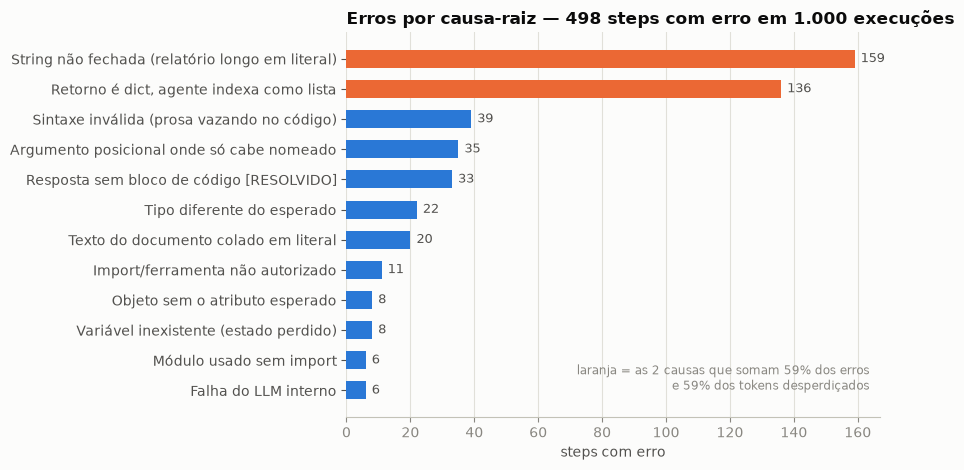

In [18]:
top = E["assinatura"].value_counts().head(12)
cores = [ORANGE if i < 2 else BLUE for i in range(len(top))]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(top.index[::-1], top.values[::-1], color=cores[::-1], height=0.6)
for i, v in enumerate(top.values[::-1]):
    ax.text(v + top.max()*0.012, i, f"{v}", va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Erros por causa-raiz — 498 steps com erro em 1.000 execuções")
ax.set_xlabel("steps com erro")
ax.text(0.98, 0.06, "laranja = as 2 causas que somam 59% dos erros\ne 59% dos tokens desperdiçados",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=MUTED)
plt.tight_layout(); plt.show()

### 8.2 · O resultado central: o agente lê o erro e reincide

Cada barra é um subconjunto da anterior. A queda de 430 → 76 é o que **não** vira problema; os 51 do fim são a
evidência de que o feedback dentro da trajetória não corrige.

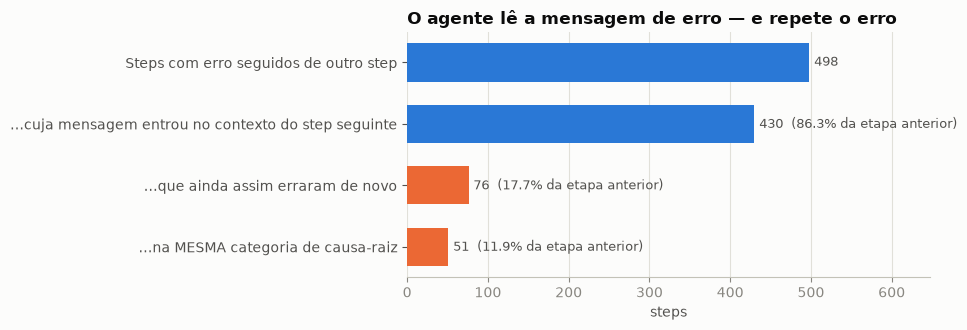

In [19]:
etapas = [
    ("Steps com erro seguidos de outro step", checked, None),
    ("…cuja mensagem entrou no contexto do step seguinte", reached, checked),
    ("…que ainda assim erraram de novo", repeated, reached),
    ("…na MESMA categoria de causa-raiz", same_sig, reached),
]
labels = [e[0] for e in etapas][::-1]
vals   = [e[1] for e in etapas][::-1]
cores  = [ORANGE, ORANGE, BLUE, BLUE]

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.barh(labels, vals, color=cores, height=0.62)
for i, (lab, v, base) in enumerate(list(etapas)[::-1]):
    txt = f"{v}" if base is None else f"{v}  ({v/base:.1%} da etapa anterior)"
    ax.text(v + checked*0.012, i, txt, va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("O agente lê a mensagem de erro — e repete o erro")
ax.set_xlabel("steps"); ax.set_xlim(0, checked*1.30)
plt.tight_layout(); plt.show()

### 8.3 · Erro é custo, não falha

Nenhuma trajetória termina em erro — todas se recuperam. O preço aparece em tokens e em passos. As duas medidas
têm grandezas incomparáveis, então são **dois painéis com escalas próprias**, nunca dois eixos no mesmo gráfico.

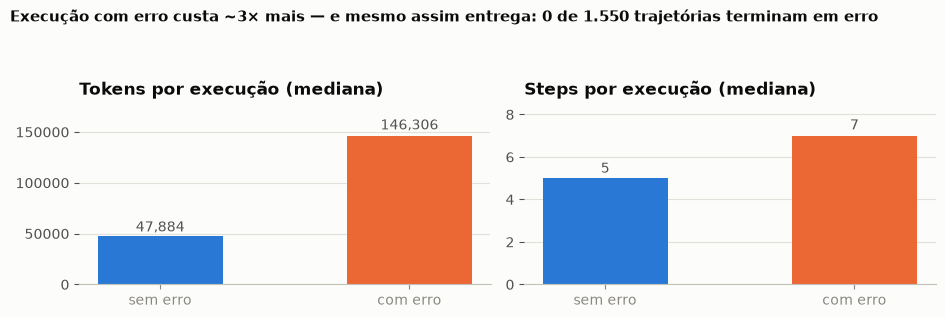

In [20]:
med = execs.groupby("com_erro")[["tok_tot","n_steps"]].median()
sem, com = med.loc[False], med.loc[True]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, campo, titulo, fmt, div in [
    (a1, "tok_tot", "Tokens por execução (mediana)", "{:,.0f}", 1),
    (a2, "n_steps", "Steps por execução (mediana)", "{:.0f}", 1)]:
    v = [med.loc[False, campo]/div, med.loc[True, campo]/div]
    b = ax.bar(["sem erro","com erro"], v, color=[BLUE, ORANGE], width=0.5)
    for rect, val in zip(b, v):
        ax.text(rect.get_x()+rect.get_width()/2, val*1.02, fmt.format(val),
                ha="center", va="bottom", color=INK2, fontsize=10)
    ax.set_title(titulo); style_ax(ax, xgrid=False); ax.set_ylim(0, max(v)*1.22)
fig.suptitle("Execução com erro custa ~3× mais — e mesmo assim entrega: 0 de 1.550 trajetórias terminam em erro",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.90]); plt.show()

### 8.4 · A mesma causa reaparece mês após mês

Cada célula é o número de erros daquela causa naquele mês de referência. Células escuras espalhadas na horizontal
mostram que o sistema **não aprende entre execuções**: repete a mesma falha ao longo de quase toda a amostra.

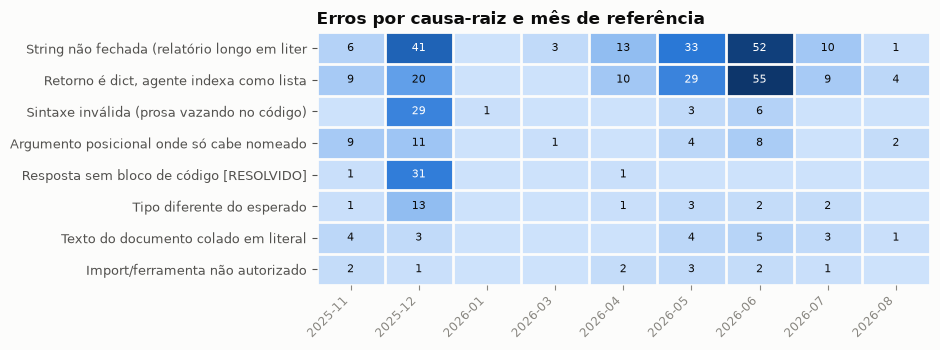

In [21]:
from matplotlib.colors import LinearSegmentedColormap
RAMP = LinearSegmentedColormap.from_list("blue_seq",
        ["#cde2fb","#9ec5f4","#5598e7","#2a78d6","#1c5cab","#0d366b"])

piv = (E.pivot_table(index="assinatura", columns="mes", values="exec_id",
                     aggfunc="count").fillna(0))
piv = piv.loc[E["assinatura"].value_counts().head(8).index]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
im = ax.imshow(piv.values, cmap=RAMP, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([s[:44] for s in piv.index], fontsize=9)
vmax = piv.values.max()
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=8,
                    color="#ffffff" if v > vmax*0.45 else INK)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(np.arange(-.5, len(piv.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(piv.index), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2); ax.tick_params(which="minor", length=0)
ax.set_title("Erros por causa-raiz e mês de referência")
plt.tight_layout(); plt.show()

### 8.5 · Onde a memória pagaria mais

Tokens gastos em steps que terminaram em erro — output descartado. É o argumento econômico para priorizar
quais unidades de memória escrever primeiro.

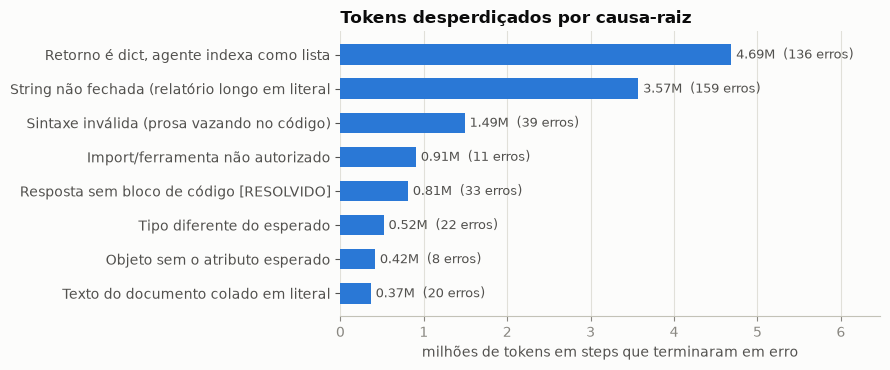

In [22]:
pay = payoff.head(8).sort_values("tokens")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh([s[:46] for s in pay.index], pay["tokens"]/1e6, color=BLUE, height=0.6)
for i, (v, e) in enumerate(zip(pay["tokens"]/1e6, pay["erros"])):
    ax.text(v + pay["tokens"].max()/1e6*0.012, i, f"{v:.2f}M  ({e} erros)",
            va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Tokens desperdiçados por causa-raiz")
ax.set_xlabel("milhões de tokens em steps que terminaram em erro")
ax.set_xlim(0, (pay["tokens"].max()/1e6)*1.38)
plt.tight_layout(); plt.show()

### 8.6 · Onde o erro acontece — e quem erra

Dois recortes de diagnóstico. À esquerda, a posição do step na trajetória, **restrita aos índices com amostra
suficiente** e com o `n` impresso em cada barra (sem isso a leitura seria enganosa). À direita, a taxa por papel.

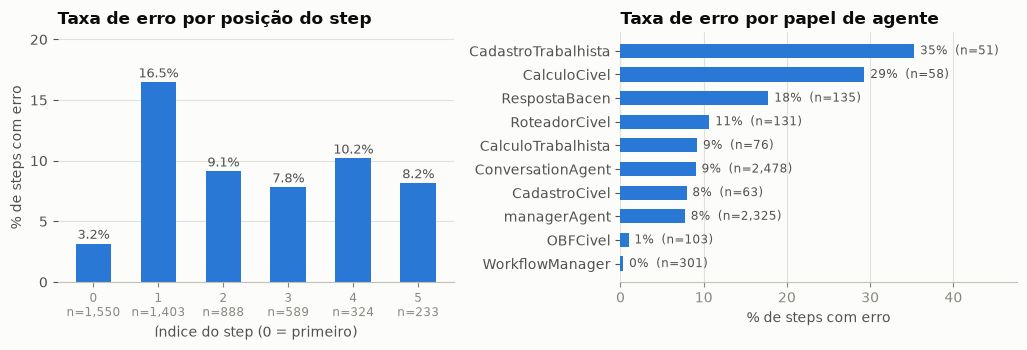

In [23]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.6))

gg = steps.groupby("idx").agg(n=("err_type","size"), e=("err_type", lambda s: s.notna().sum()))
gg = gg[gg["n"] >= 200]; gg["taxa"] = gg["e"]/gg["n"]*100
a1.bar(range(len(gg)), gg["taxa"], color=BLUE, width=0.55)
for x, taxa in enumerate(gg["taxa"]):
    a1.text(x, taxa + 0.4, f"{taxa:.1f}%", ha="center", color=INK2, fontsize=9)
a1.set_xticks(range(len(gg)))
a1.set_xticklabels([f"{i}\nn={n:,}" for i, n in zip(gg.index, gg["n"])], fontsize=8.5)
a1.set_title("Taxa de erro por posição do step")
a1.set_xlabel("índice do step (0 = primeiro)"); a1.set_ylabel("% de steps com erro")
a1.set_ylim(0, gg["taxa"].max()*1.25); style_ax(a1, xgrid=False)

pr = (steps.groupby("role").agg(n=("err_type","size"), e=("err_type", lambda s: s.notna().sum())))
pr = pr[pr["n"] >= 30]; pr["taxa"] = pr["e"]/pr["n"]*100
pr = pr.sort_values("taxa")
a2.barh(pr.index, pr["taxa"], color=BLUE, height=0.6)
for i, (taxa, n) in enumerate(zip(pr["taxa"], pr["n"])):
    a2.text(taxa + pr["taxa"].max()*0.02, i, f"{taxa:.0f}%  (n={n:,})", va="center", color=INK2, fontsize=8.5)
a2.set_title("Taxa de erro por papel de agente"); a2.set_xlabel("% de steps com erro")
a2.set_xlim(0, pr["taxa"].max()*1.35); style_ax(a2)
plt.tight_layout(); plt.show()

### 8.7 · Concentração de custo — curva de Lorenz

Cada ponto no eixo x é "as N% execuções mais caras"; o eixo y é a fatia do gasto total que elas carregam. A
linha tracejada é a distribuição perfeitamente igualitária (se todas as execuções custassem o mesmo). Quanto
mais a curva azul se afasta da diagonal, mais concentrado é o custo.

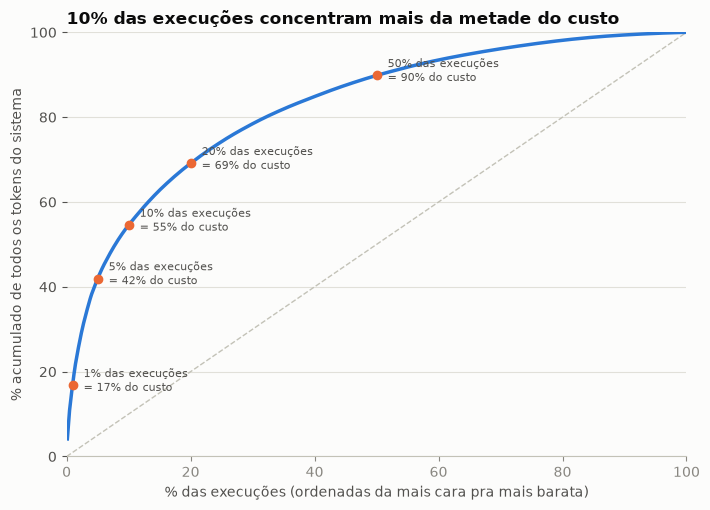

In [24]:
toks_desc = execs["tok_tot"].sort_values(ascending=False).values
cum = np.cumsum(toks_desc) / toks_desc.sum() * 100
x = np.arange(1, len(toks_desc) + 1) / len(toks_desc) * 100

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot([0, 100], [0, 100], color=BASE, linewidth=1, linestyle="--")
ax.plot(x, cum, color=BLUE, linewidth=2.5)
for pct in (1, 5, 10, 20, 50):
    idx = max(1, round(len(toks_desc) * pct / 100)) - 1
    ax.scatter([x[idx]], [cum[idx]], color=ORANGE, zorder=5, s=36)
    ax.annotate(f"{pct}% das execuções\n= {cum[idx]:.0f}% do custo", (x[idx], cum[idx]),
                textcoords="offset points", xytext=(8, -4), fontsize=8, color=INK2)
ax.set_xlabel("% das execuções (ordenadas da mais cara pra mais barata)")
ax.set_ylabel("% acumulado de todos os tokens do sistema")
ax.set_title("10% das execuções concentram mais da metade do custo")
style_ax(ax, xgrid=False)
ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

### 8.8 · Assinatura de erro por papel

Cada barra soma 100% dos erros daquele papel. `CadastroTrabalhista` e `CalculoCivel` têm uma única cor
dominando quase a barra inteira — é o que "94%" e "76%" parecem visualmente.

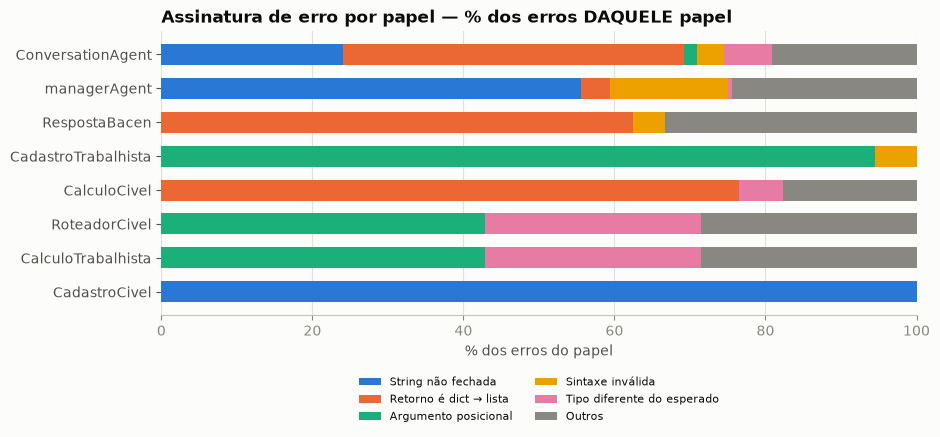

In [25]:
CAT = ["String não fechada (relatório longo em literal)", "Retorno é dict, agente indexa como lista",
       "Argumento posicional onde só cabe nomeado", "Sintaxe inválida (prosa vazando no código)",
       "Tipo diferente do esperado"]
CAT_CORES = [BLUE, ORANGE, "#1baf7a", "#eda100", "#e87ba4"]  # paleta categórica, ordem fixa (skill dataviz)

role_vol2 = E["role"].value_counts()
roles_ord = role_vol2[role_vol2 >= 5].sort_values().index
tab_rf = pd.crosstab(E["role"], E["assinatura"]).reindex(roles_ord)
norm8 = tab_rf[[c for c in CAT if c in tab_rf.columns]].div(tab_rf.sum(axis=1), axis=0) * 100
norm8["Outros"] = (100 - norm8.sum(axis=1)).clip(lower=0)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
left = np.zeros(len(norm8))
LABEL_CURTO = {
    "String não fechada (relatório longo em literal)": "String não fechada",
    "Retorno é dict, agente indexa como lista": "Retorno é dict → lista",
    "Argumento posicional onde só cabe nomeado": "Argumento posicional",
    "Sintaxe inválida (prosa vazando no código)": "Sintaxe inválida",
    "Tipo diferente do esperado": "Tipo diferente do esperado",
}
cores8 = CAT_CORES + [MUTED]
for i, col in enumerate(norm8.columns):
    ax.barh(norm8.index, norm8[col], left=left, color=cores8[i % len(cores8)], height=0.62,
            label=LABEL_CURTO.get(col, col))
    left += norm8[col].values
ax.set_xlim(0, 100)
ax.set_title("Assinatura de erro por papel — % dos erros DAQUELE papel")
ax.set_xlabel("% dos erros do papel")
style_ax(ax, xgrid=False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### 8.9 · Tokens por chamada de ferramenta, por papel

Eficiência por unidade de trabalho real — eixo independente da taxa de erro (§2.1). Em laranja, os papéis
acima de 2× a **mediana por execução** (12.192) — não a razão agregada, que é outra estatística (ver §3.3).

> `null` e `ontestacaoCivel` (nome truncado de `ContestacaoCivel`) são artefatos de serialização do campo de
> papel na fonte, não papéis "de verdade" — aparecem no gráfico porque o dado é real, mas não valem decisão
> de priorização sem investigar a causa da chave malformada primeiro.

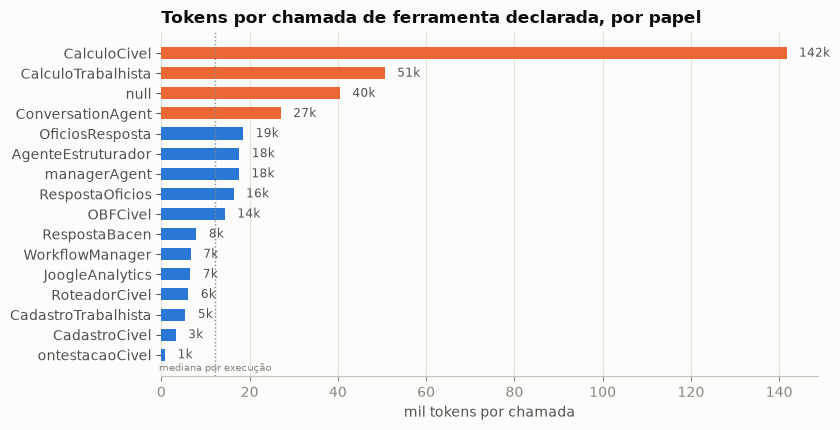

In [26]:
efp = EF.sort_values("tok_por_chamada")
# CORRIGIDO (auditoria independente, S1): a referência é a MEDIANA das razões por execução
# (12.192), não a razão agregada soma/soma (21.420). Rotular a agregada como "mediana" era o
# mesmo erro que §3.3 já tinha corrigido na prosa — o gráfico tinha ficado de fora.
cores9 = [ORANGE if v > mediana_por_exec * 2 else BLUE for v in efp["tok_por_chamada"]]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(efp["role"], efp["tok_por_chamada"] / 1000, color=cores9, height=0.6)
for i, v in enumerate(efp["tok_por_chamada"] / 1000):
    ax.text(v + efp["tok_por_chamada"].max() / 1000 * 0.02, i, f"{v:.0f}k", va="center", color=INK2, fontsize=8.5)
ax.axvline(mediana_por_exec / 1000, color=MUTED, linewidth=1, linestyle=":")
ax.text(mediana_por_exec / 1000, -0.8, "mediana por execução", color=MUTED, fontsize=7.5, ha="center")
ax.set_title("Tokens por chamada de ferramenta declarada, por papel")
ax.set_xlabel("mil tokens por chamada")
style_ax(ax)
plt.tight_layout(); plt.show()

### 8.10 · A prioridade muda conforme o critério

O mesmo conjunto de papéis, ranqueado duas vezes: por percentual do próprio orçamento desperdiçado, e por
volume absoluto de tokens desperdiçados. As linhas cruzando mostram a reordenação.

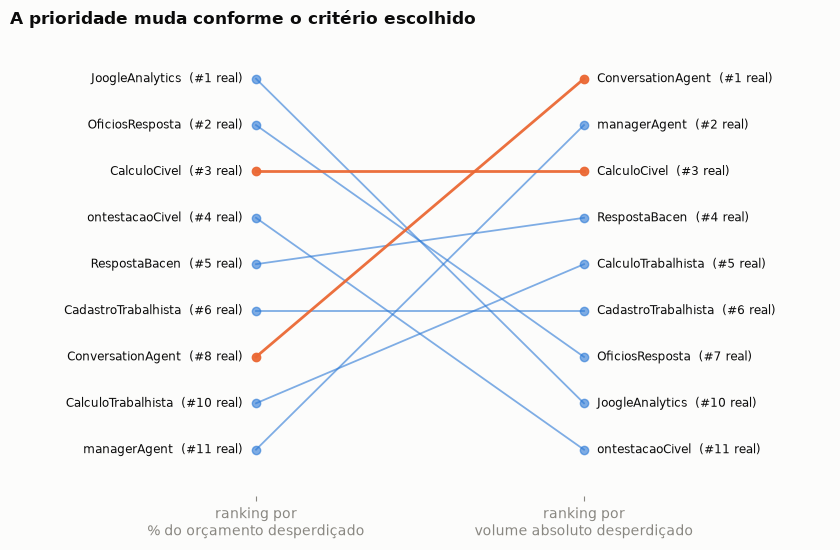

In [27]:
rank_pct = {r: i for i, r in enumerate(OR.sort_values("%_desperdicado", ascending=False).index)}
rank_abs = {r: i for i, r in enumerate(OR.sort_values("tok_erro", ascending=False).index)}
roles_show = set(list(rank_pct)[:6]) | set(list(rank_abs)[:6])

# posições verticais COMPACTAS (0..n-1) para os papéis exibidos — usar o rank bruto (que pode ter
# buracos, já que só mostramos um subconjunto) causava rótulos sobrepostos no canto de amostra maior.
left_order = sorted(roles_show, key=lambda r: rank_pct[r])
right_order = sorted(roles_show, key=lambda r: rank_abs[r])
y_left = {r: i for i, r in enumerate(left_order)}
y_right = {r: i for i, r in enumerate(right_order)}

fig, ax = plt.subplots(figsize=(8.5, 5.6))
for r in roles_show:
    y1, y2 = y_left[r], y_right[r]
    destaque = r in ("CalculoCivel", "ConversationAgent")
    cor = ORANGE if destaque else BLUE
    ax.plot([0, 1], [y1, y2], color=cor, linewidth=2 if destaque else 1.3,
            alpha=0.95 if destaque else 0.6, marker="o", markersize=6, zorder=3 if destaque else 2)
    ax.text(-0.04, y1, f"{r}  (#{rank_pct[r]+1} real)", ha="right", va="center", fontsize=8.5, color=INK)
    ax.text(1.04, y2, f"{r}  (#{rank_abs[r]+1} real)", ha="left", va="center", fontsize=8.5, color=INK)
ax.set_xlim(-0.75, 1.75)
ax.set_ylim(len(roles_show), -1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["ranking por\n% do orçamento desperdiçado", "ranking por\nvolume absoluto desperdiçado"])
for s in ax.spines.values(): s.set_visible(False)
ax.set_yticks([])
ax.set_title("A prioridade muda conforme o critério escolhido")
plt.tight_layout(); plt.show()

### 8.11 · Evolução mensal do custo por execução

Barras em cinza são meses com amostra pequena demais pra confiar (`n < 20`).

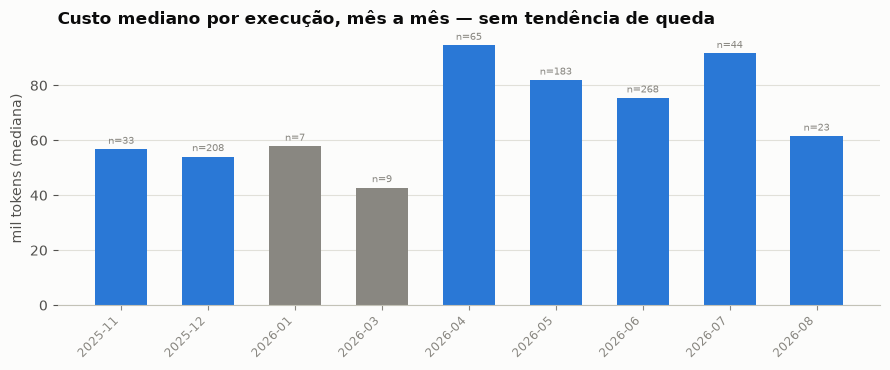

In [28]:
pm = execs.groupby("mes")["tok_tot"].median()
n_pm = execs.groupby("mes").size()
cores11 = [MUTED if n_pm[m] < 20 else BLUE for m in pm.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(len(pm)), pm.values / 1000, color=cores11, width=0.6)
for i, m in enumerate(pm.index):
    ax.text(i, pm[m] / 1000 + 2, f"n={n_pm[m]}", ha="center", color=MUTED, fontsize=7.5)
ax.set_xticks(range(len(pm))); ax.set_xticklabels(pm.index, rotation=45, ha="right", fontsize=8.5)
ax.set_title("Custo mediano por execução, mês a mês — sem tendência de queda")
ax.set_ylabel("mil tokens (mediana)")
style_ax(ax, xgrid=False)
ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### 8.12 · Sucesso verificado por conteúdo

Continuação do funil da seção 8.2, agora checando o CONTEÚDO da resposta, não só se `final_answer` foi
chamado.

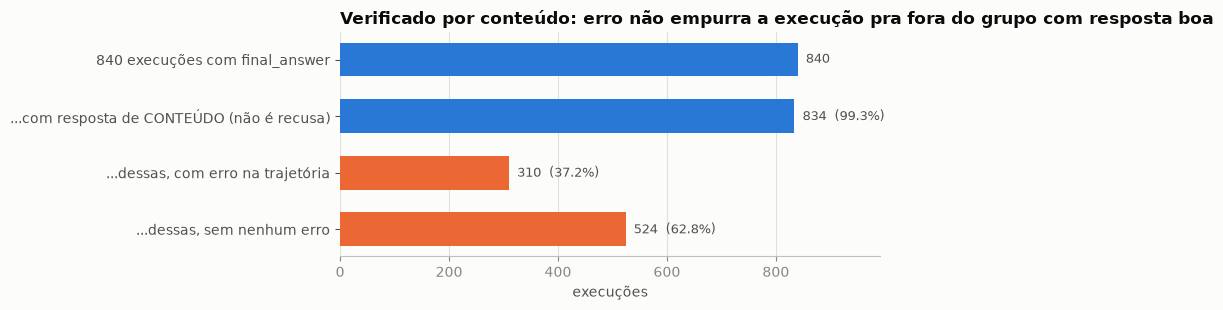

In [29]:
labels12 = ["840 execuções com final_answer", "...com resposta de CONTEÚDO (não é recusa)",
            "...dessas, com erro na trajetória", "...dessas, sem nenhum erro"]
vals12 = [len(S), int(S["sucesso"].sum()), int((S["sucesso"] & S["com_erro"]).sum()),
          int((S["sucesso"] & ~S["com_erro"]).sum())]
cores12 = [BLUE, BLUE, ORANGE, ORANGE]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(labels12[::-1], vals12[::-1], color=cores12[::-1], height=0.6)
# denominador de cada percentual: os 2 primeiros são % de 840 (total); os 2 últimos são % de 834
# (as com resposta de conteúdo) — usar 840 nos 4 daria número errado (36,9% em vez de 37,2%).
bases12 = [None, len(S), int(S["sucesso"].sum()), int(S["sucesso"].sum())]
for i, (v, base) in enumerate(zip(vals12[::-1], bases12[::-1])):
    pct = f"  ({v/base:.1%})" if base else ""
    ax.text(v + 15, i, f"{v}{pct}", va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Verificado por conteúdo: erro não empurra a execução pra fora do grupo com resposta boa")
ax.set_xlabel("execuções"); ax.set_xlim(0, len(S) * 1.18)
plt.tight_layout(); plt.show()

## 9 · Candidatos a unidades de memória

Regra de triagem, agora fundamentada no AgentDebug (o **módulo que produziu o erro** roteia o tipo de memória) e
na sua política de escrita (**uma unidade por cascata, na raiz** — não uma por step com erro).

In [30]:
CAND = [
 ("Contrato de retorno das ferramentas de documento", "semântica",
  "get_available_documents() e similares retornam {'result': [[...]]} — acessar r['result'][0], nunca r[0].",
  "Retorno é dict, agente indexa como lista"),
 ("Relatório longo nunca dentro de literal de string", "procedural",
  "Montar a resposta com variáveis/concatenação e só então passar a final_answer; não colar markdown/tabela em literal.",
  "String não fechada (relatório longo em literal)"),
 ("Toda ferramenta desta esteira exige argumento NOMEADO", "procedural",
  "Chamar sempre f(arg=valor); nenhuma tool aceita posicional. Vale para as 12 ferramentas observadas.",
  "Argumento posicional onde só cabe nomeado"),
 ("Inventário do sandbox", "semântica",
  "Imports autorizados; json/pandas exigem import explícito no snippet; openpyxl ausente — usar envia_excel_para_usuario.",
  "Import/ferramenta não autorizado"),
 ("Após step com erro, a variável não existe", "experiencial-procedural",
  "Se a observação anterior traz exceção, re-derivar o que aquele step criaria; nunca reusar a variável.",
  "Variável inexistente (estado perdido)"),
 ("Não é memória — política de harness", "harness",
  "AgentGenerationError/422: retry com backoff e circuit breaker por subagente.",
  "Falha do LLM interno"),
]
tbl = []
for nome, tipo, conteudo, assinatura in CAND:
    sub_e = E[E["assinatura"] == assinatura]
    tbl.append({"candidato": nome, "tipo": tipo, "erros": len(sub_e),
                "execuções": sub_e["exec_id"].nunique(), "meses": sub_e["mes"].nunique(),
                "tokens": int(sub_e["tok_tot"].sum()), "conteúdo proposto": conteudo})
C = pd.DataFrame(tbl)
display(C[["candidato","tipo","erros","execuções","meses","tokens"]])

import os
os.makedirs("resultados", exist_ok=True)
C.to_csv("resultados/candidatos_memoria.csv", index=False)
payoff.to_csv("resultados/payoff_assinaturas.csv")
rec.to_csv("resultados/reincidencia.csv")
E.assign(err_msg=E["err_msg"].str.slice(0,400)).to_csv("resultados/erros_classificados.csv", index=False)
execs.to_csv("resultados/execucoes.csv", index=False)
print("Exportado para resultados/")

,candidato,tipo,erros,execuções,meses,tokens
0,Contrato de retorno das ferramentas de documento,semântica,136,119,7,4687425
1,Relatório longo nunca dentro de literal de string,procedural,159,125,8,3572698
2,Toda ferramenta desta esteira exige argumento ...,procedural,35,22,6,364543
3,Inventário do sandbox,semântica,11,11,6,907471
4,"Após step com erro, a variável não existe",experiencial-procedural,8,7,4,299222
5,Não é memória — política de harness,harness,6,6,3,23249


Exportado para resultados/


## 10 · Leitura dos resultados

Síntese narrativa em [`../docs/02-relatorio-achados.md`](../docs/02-relatorio-achados.md); fichamentos dos papers em
[`../literature/`](../literature/).